In [1]:
import numpy as np
import scipy
from scipy.fft import fft, fftfreq, rfft, rfftfreq, ifft, irfft
import torch
from torch.utils.data import Dataset
import random

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

# Tutorial

# DHO

In [2]:
priors = dict()
priors['omega_0'] = scipy.stats.uniform(loc=0.1, scale=1.9)
priors['beta'] = scipy.stats.uniform(loc=0, scale=0.5)
priors['shift'] = scipy.stats.uniform(loc=-4, scale=8)

In [3]:
def damped_sho(t, omega_0, beta, shift=0):
    # beta less than 1 for underdamped
    envel = beta * omega_0
    osc = torch.sqrt(1 - beta**2) * omega_0
    tau = t - shift
    data = torch.exp(-envel * tau) * torch.cos(osc * tau)
    data[tau < 0] = 0  # assume oscillator starts at tau = 0
    return data

In [4]:
omega_0 = 4*np.pi #priors['omega_0'].rvs()
omega_0 = torch.as_tensor(omega_0, dtype=torch.float32).clone().detach()
beta = priors['beta'].rvs()
beta = torch.as_tensor(beta, dtype=torch.float32).clone().detach()
shift = priors['shift'].rvs()
shift = torch.as_tensor(shift, dtype=torch.float32).clone().detach()

t_vals = torch.linspace(0, 10, 200).to(dtype=torch.float32).repeat(10, 1)

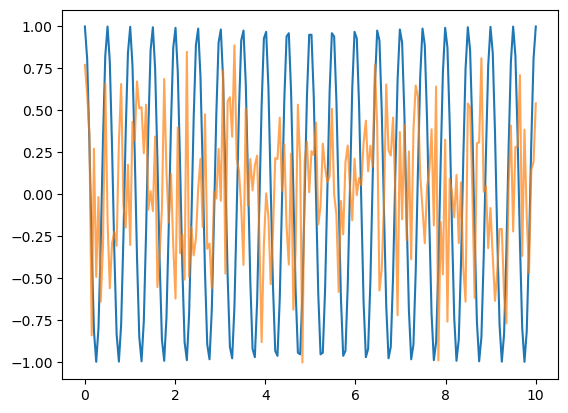

In [5]:
y_clean = damped_sho(t=t_vals, omega_0=omega_0, beta=torch.as_tensor(0), shift=torch.as_tensor(-10))
y_noise = 0.4 * torch.randn(size=y_clean.size()).to(dtype=torch.float32)
plt.plot(t_vals[0], y_clean[0])
plt.plot(t_vals[0], y_noise[0], alpha=0.7)

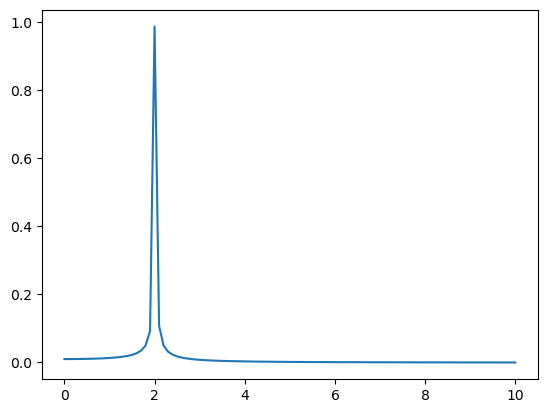

In [6]:
yf_clean = rfft(y_clean.numpy().astype(np.longdouble), n=200)
xf_clean = rfftfreq(n=200, d=10/200)
plt.plot(xf_clean, 2/200 * np.abs(yf_clean[0]))

/work/submit/kyoon/miniforge3/envs/ssm/lib/python3.10/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/work/submit/kyoon/miniforge3/envs/ssm/lib/python3.10/site-packages/matplotlib/collections.py:197: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


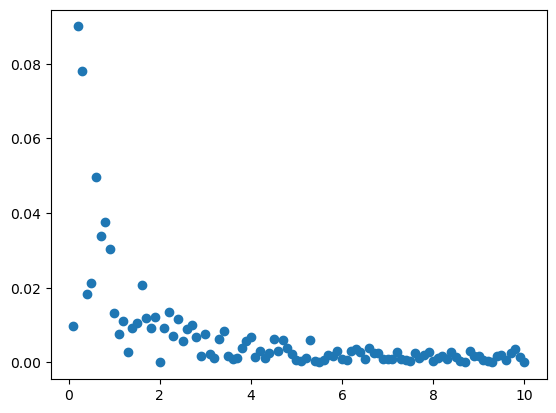

In [7]:
yf_noise = rfft(y_noise.numpy().astype(np.longdouble), n=200)
xf_noise = rfftfreq(n=200, d=10/200)
plt.scatter(xf_noise[1:], 2/200 * np.sqrt(yf_noise[0][1:])/(xf_noise[1:]))

/tmp/ipykernel_353297/4073794633.py:2: ComplexWarning: Casting complex values to real discards the imaginary part
  yf[0] = yf_clean[0]
/tmp/ipykernel_353297/4073794633.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  yf[1:] = yf_clean[1:] + yf_noise[1:] #/xf_noise[1:]


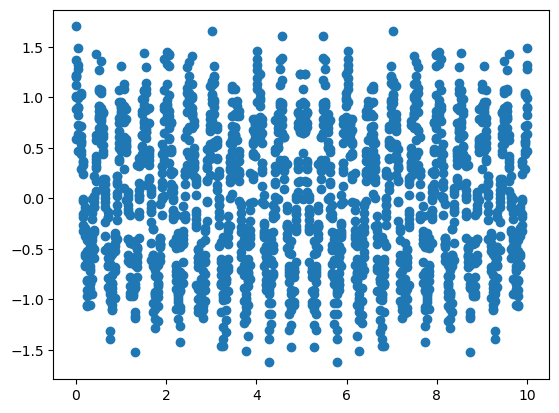

In [8]:
yf = np.zeros(yf_clean.shape)
yf[0] = yf_clean[0]
yf[1:] = yf_clean[1:] + yf_noise[1:] #/xf_noise[1:]
plt.scatter(t_vals, irfft(yf))

# Gen Noise Spectrum (example)

In [9]:
freqs = np.linspace(0, 10, 200)
psd = np.zeros(200)

psd += freqs**2
psd = psd/psd.sum()

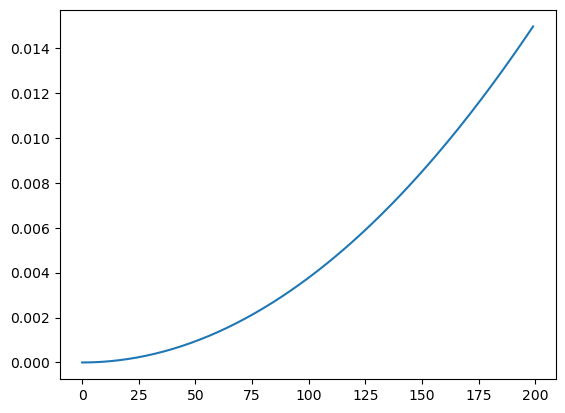

In [10]:
plt.plot(psd)

In [100]:
t_vals = torch.linspace(-1,10,200).repeat(10,1)

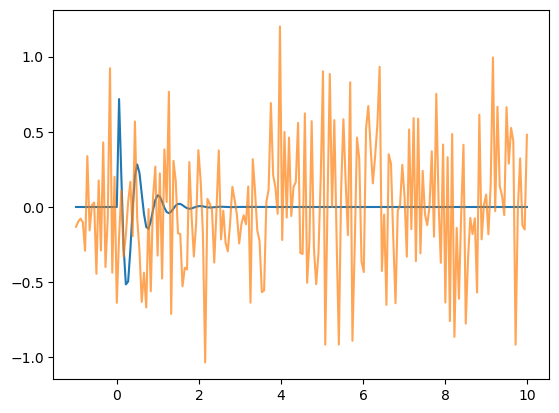

In [101]:
y_clean = damped_sho(t=t_vals, omega_0=omega_0, beta=torch.as_tensor(0.2), shift=torch.as_tensor(0))
y_noise = 0.4 * torch.randn(size=t_vals.size()).to(dtype=torch.float32)
plt.plot(t_vals[0], y_clean[0])
plt.plot(t_vals[0], y_noise[0], alpha=0.7)

In [102]:
y_noise.std()

tensor(0.3983)

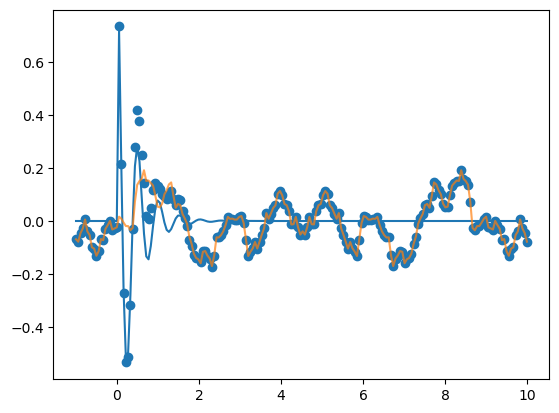

In [38]:
xf_clean = rfftfreq(n=200, d=11/200)
# yf_noise = torch.tensor(torch.pi / 0.4) * torch.randn(len(xf_clean))
yf_noise = 0.1 * torch.sqrt(torch.tensor(200)) * torch.randn(len(xf_clean))
yf_noise[1:] = yf_noise[1:]/xf_clean[1:]
plt.plot(t_vals[0], y_clean[0])
plt.plot(t_vals[0], torch.fft.irfft(yf_noise), alpha=0.7)
plt.scatter(t_vals[0], y_clean[0] + torch.fft.irfft(yf_noise))

In [41]:
(y_clean[0]**2).mean() / (torch.fft.irfft(yf_noise)**2).mean()

tensor(1.0201)

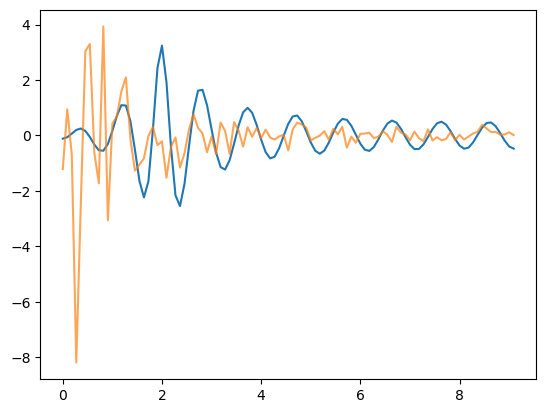

In [42]:
plt.plot(xf_clean, torch.fft.rfft(y_clean[0]))
plt.plot(xf_clean, yf_noise, alpha=0.7)

In [17]:
xf_clean

array([ 0.  ,  0.05,  0.1 ,  0.15,  0.2 ,  0.25,  0.3 ,  0.35,  0.4 ,
        0.45,  0.5 ,  0.55,  0.6 ,  0.65,  0.7 ,  0.75,  0.8 ,  0.85,
        0.9 ,  0.95,  1.  ,  1.05,  1.1 ,  1.15,  1.2 ,  1.25,  1.3 ,
        1.35,  1.4 ,  1.45,  1.5 ,  1.55,  1.6 ,  1.65,  1.7 ,  1.75,
        1.8 ,  1.85,  1.9 ,  1.95,  2.  ,  2.05,  2.1 ,  2.15,  2.2 ,
        2.25,  2.3 ,  2.35,  2.4 ,  2.45,  2.5 ,  2.55,  2.6 ,  2.65,
        2.7 ,  2.75,  2.8 ,  2.85,  2.9 ,  2.95,  3.  ,  3.05,  3.1 ,
        3.15,  3.2 ,  3.25,  3.3 ,  3.35,  3.4 ,  3.45,  3.5 ,  3.55,
        3.6 ,  3.65,  3.7 ,  3.75,  3.8 ,  3.85,  3.9 ,  3.95,  4.  ,
        4.05,  4.1 ,  4.15,  4.2 ,  4.25,  4.3 ,  4.35,  4.4 ,  4.45,
        4.5 ,  4.55,  4.6 ,  4.65,  4.7 ,  4.75,  4.8 ,  4.85,  4.9 ,
        4.95,  5.  ,  5.05,  5.1 ,  5.15,  5.2 ,  5.25,  5.3 ,  5.35,
        5.4 ,  5.45,  5.5 ,  5.55,  5.6 ,  5.65,  5.7 ,  5.75,  5.8 ,
        5.85,  5.9 ,  5.95,  6.  ,  6.05,  6.1 ,  6.15,  6.2 ,  6.25,
        6.3 ,  6.35,

(array([14., 12., 42., 44., 74., 44., 41., 36., 46., 34., 18.,  4., 18.,
         6.,  6.,  2., 24., 21.,  8.,  6.]),
 array([-1.16032326, -1.00926268, -0.85820216, -0.70714158, -0.55608106,
        -0.40502048, -0.25395992, -0.10289936,  0.0481612 ,  0.19922176,
         0.35028231,  0.50134289,  0.65240341,  0.803464  ,  0.95452452,
         1.1055851 ,  1.25664568,  1.40770626,  1.55876672,  1.7098273 ,
         1.86088789]),
 <BarContainer object of 20 artists>)

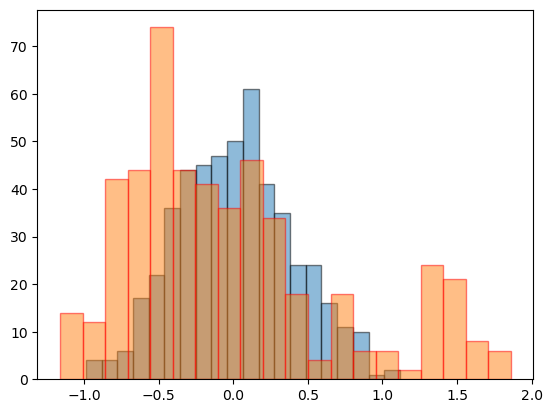

In [14]:
plt.hist(y_noise[0], bins=20, edgecolor='black', alpha=0.5)
plt.hist(torch.fft.irfft(yf_noise), bins=20, edgecolor='red', alpha=0.5)

# Colorednoise package

In [58]:
import colorednoise as cn

In [165]:
t_vals = torch.linspace(-10,10,500)
signal = damped_sho(t=t_vals, omega_0=omega_0, beta=torch.as_tensor(0.2), shift=torch.as_tensor(0))
noise = 0.4*torch.tensor(cn.powerlaw_psd_gaussian(1, size=t_vals.shape, random_state=42), dtype=torch.float32) # pink noise

Fourier space

In [123]:
tf = torch.fft.rfftfreq(n=200, d=11/200)
sf = torch.fft.rfft(signal)
nf = torch.fft.rfft(noise)

/work/submit/kyoon/miniforge3/envs/ssm/lib/python3.10/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/work/submit/kyoon/miniforge3/envs/ssm/lib/python3.10/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


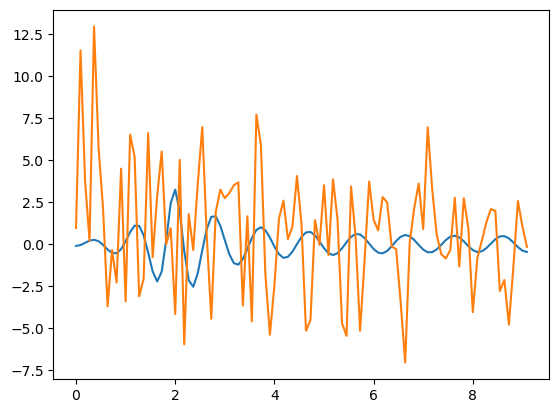

In [124]:
plt.plot(tf, sf)
plt.plot(tf, nf)

Oscillation noise

In [125]:
t_vals = torch.linspace(-1,10,200)
signal = damped_sho(t=t_vals, omega_0=omega_0, beta=torch.as_tensor(0.2), shift=torch.as_tensor(0))
noise = 0.5 * torch.sin(2 * torch.pi * t_vals)